# Prédiction du départ des clients (Churn)

Pour ce projet, j'ai voulu travailler sur un vrai problème d'entreprise: prédire quels clients d'un opérateur télécom risquent de résilier leur abonnement (ce qu'on appelle le *churn*). L'idée, c'est qu'en repérant ces clients à l'avance, une entreprise peut essayer de les retenir avant qu'ils ne partent.

J'ai utilisé le dataset **Telco Customer Churn** (disponible gratuitement sur le site Kaggle), qui contient les informations de 7043 clients : leur ancienneté, leur type de contrat, leurs services, leur facturation, etc.

**Ma démarche :**
1. **Exploration et nettoyage** — comprendre les données et repérer les pièges 
   (j'ai notamment trouvé une colonne mal typée à cause de valeurs vides cachées).
2. **Préparation** — transformer les variables catégorielles en variables 
   numériques et séparer les données en jeu d'entraînement / jeu de test.
3. **Modélisation** — entraîner et comparer plusieurs modèles 
   (régression logistique, Random Forest).
4. **Évaluation** — choisir le modèle non pas sur l'accuracy (trompeuse ici 
   à cause du déséquilibre des classes), mais sur sa capacité à vraiment 
   repérer les clients qui partent.

Ce projet m'a permis de mettre en pratique tout le cycle d'un problème de 
machine learning, de la donnée brute jusqu'à un modèle prêt à être réutilisé.

**Importation des bibliothèques nécessaires** (pandas, scikit-learn, etc.)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

## 1. Exploration et nettoyage des données

Avant de construire quoi que ce soit, je commence par regarder les données 
de près : comprendre ce que contient chaque colonne, vérifier les types, 
et repérer les éventuels problèmes. C'est souvent l'étape la plus importante : 
des données sales donnent un modèle qui ne vaut rien.

In [4]:

#charger les données dans un DataFrame
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

df.info()

#la colonne que nous allons prédire est "Churn", qui indique si un client a quitté ou non l'entreprise. Nous allons convertir cette colonne en une variable binaire, où 1 signifie que le client a quitté et 0 signifie qu'il est resté.
df["Churn"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
#Actuellement, la colonne "TotalCharges" est du texte. En regardant les données, on voit que certaines lignes ont un espace vide dans cette colonne, ce qui pose problème pour la conversion en nombre.
# On essaie de convertir la colonne "TotalCharges" (actuellement du texte) en nombres.
# errors="coerce" signifie : "si une valeur ne peut pas devenir un nombre (ex: un espace vide),
# remplace-la par NaN" (NaN = Not a Number, c'est la façon dont pandas note une case vide).
totaux = pd.to_numeric(df["TotalCharges"], errors="coerce")

# .isna() renvoie True pour chaque case vide (NaN), False sinon.
# .sum() additionne les True (chaque True compte pour 1) → ça nous donne le NOMBRE de cases vides.
# C'est donc le nombre de lignes qui posaient problème (les espaces déguisés).
print("Nombre de valeurs problématiques :", totaux.isna().sum())

Nombre de valeurs problématiques : 11


In [6]:
#on peut aussi afficher les lignes problématiques pour les examiner de plus près :
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
# 1. On convertit définitivement TotalCharges en nombres.
#    Les 11 espaces vides deviennent NaN (cases vides).
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 2. On remplace ces 11 NaN par 0, car ce sont des clients nouveaux
#    (tenure = 0) qui n'ont encore rien payé : leur total est logiquement 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 3. On vérifie que tout est réglé :
#    - le type doit maintenant être float (un nombre), plus "object"
#    - il ne doit plus rester aucune valeur manquante
print("Type de la colonne :", df["TotalCharges"].dtype)
print("Valeurs manquantes restantes :", df["TotalCharges"].isna().sum())

Type de la colonne : float64
Valeurs manquantes restantes : 0


> **Ce que j'ai trouvé :** la colonne `TotalCharges` était stockée comme du texte 
> alors qu'elle devrait contenir des montants. En cherchant, j'ai vu que 11 lignes 
> contenaient un espace vide au lieu d'un chiffre. Ce sont en fait des clients tout 
> nouveaux (`tenure = 0`) qui n'ont pas encore reçu leur première facture. 
> Comme leur total est logiquement nul, je l'ai remplacé par 0.

In [8]:
#supprimer les colonnes inutiles pour la prédiction 
df = df.drop("customerID", axis=1)

print(df.shape[1])

20


In [9]:
#verifier combien de client sont partis ou resté en pourcentage
#No -> le clien est resté, Yes -> le client a quitté
print(df["Churn"].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


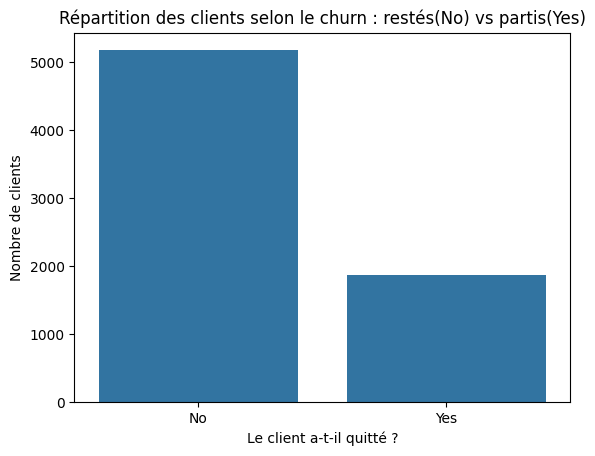

In [10]:
#nombre de client par categorie 
sns.countplot(data=df, x="Churn")
plt.title("Répartition des clients selon le churn : restés(No) vs partis(Yes)")

plt.xlabel("Le client a-t-il quitté ?")
plt.ylabel("Nombre de clients")


#afficher le graphe
plt.show()

In [11]:
#separtion des donnnées en deux parties : les caractéristiques (X) et la cible (y)

X = df.drop(columns=["Churn"]) #caractéristiques (tout sauf la colonne "Churn")

y = df["Churn"] #cible (la colonne "Churn" qu'on veut prédire) et on transforme les valeurs "Yes"/"No" en 1/0 pour que ce soit plus facile à traiter par les modèles de machine learning.
y = y.map({"Yes": 1, "No": 0})

#afficher les premières lignes de X et y pour vérifier
print("Forme de X:", X.shape)
print(y.shape)
print(y.value_counts())

Forme de X: (7043, 19)
(7043,)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [12]:
#transformer les variables catégorielles en variables numériques (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

#afficher les premières lignes de X après transformation
print(X.head())
print("Nouvelle forme de X : ", X.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

## 2. Préparation des données

Maintenant que les données sont propres, je les prépare pour le modèle. Je sépare 
ce que je veux prédire (la cible `Churn`) du reste des informations qui serviront 
à la prédiction. Je transforme aussi les colonnes texte en colonnes numériques, 
parce qu'un modèle de machine learning ne comprend que des nombres.

## 3. Modélisation

Je découpe mes données en deux : une partie pour entraîner le modèle, et une partie 
"cachée" pour le tester sur des clients qu'il n'a jamais vus. Ça me permet de vérifier 
qu'il sait vraiment généraliser, et pas juste réciter par cœur.

In [13]:
#separation des données en en jeu d'entrainemente et de jeu de test
#utilisation de train_test_split
#random_state -> pour la coupure aleatoire avec fixation d'une graine (42)
#stratify -> pour équilibrer les jeux de données (entrainement et test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train : ", X_train.shape)
print("Test : ", X_test.shape)

Train :  (5634, 30)
Test :  (1409, 30)


In [14]:
#transformer chaque colonne pour qu'elle ait une moyenne de 0 et un ecart type de 1 avec scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#creation du modèle 
#avec iter=1000 pour lui laisser le temps d'apprendre
model = LogisticRegression(max_iter=1000, class_weight="balanced")

#on l'entraine sur notre jeu d'entrainement 
model.fit(X_train_scaled, y_train)

#prediction sur le jeu de test
y_pred = model.predict(X_test_scaled)

#afficher le tauxx de bonnes reponses 
print("Accuracy : ", accuracy_score(y_test, y_pred))

#matrice de confusion 

print(confusion_matrix(y_test, y_pred))
print()

print(classification_report(y_test, y_pred))

Accuracy :  0.7402413058907026
[[749 286]
 [ 80 294]]

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [15]:
#apprentissage avec le modele Random Forest
model_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)

#entrainement et prediction
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [16]:
#entrainement avec pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

#entrainer le pipeline sur les données brutes
pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)

#
print(classification_report(y_test, y_pred_pipe))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## 4. Évaluation et choix du modèle

Ici, attention : comme il y a beaucoup plus de clients qui restent (73%) que de 
clients qui partent (27%), l'accuracy est trompeuse. Un modèle qui dirait 
"tout le monde reste" aurait 73% de bonnes réponses tout en étant inutile.

Ce qui m'intéresse vraiment, c'est le **recall sur les clients qui partent** : 
sur tous ceux qui sont réellement partis, combien le modèle arrive-t-il à repérer ? 
C'est ça qui compte pour l'entreprise.

| Modèle | Recall (partis) | F1 (partis) |
|---|---|---|
| Régression logistique | 0,57 | 0,61 |
| Régression logistique (balanced) | **0,79** | **0,62** |
| Random Forest (balanced) | 0,50 | 0,56 |

**Mon choix : la régression logistique avec `class_weight="balanced"`.** 
C'est elle qui repère le mieux les clients sur le point de partir (79%), 
et en bonus elle est plus simple et plus facile à comprendre qu'un Random Forest. 
J'ai trouvé intéressant de voir qu'un modèle plus complexe ne donne pas forcément 
de meilleurs résultats.

## 5. Sauvegarde du modèle

Pour pouvoir réutiliser mon modèle plus tard (par exemple dans une API) sans avoir 
à le réentraîner à chaque fois, je le sauvegarde dans un fichier. J'utilise un 
*pipeline* qui regroupe la mise à l'échelle et le modèle dans un seul objet, 
pour que tout le traitement se fasse automatiquement.

In [17]:
#sauvegarde du meilleure modele trouver (avec pipeline)
import joblib


joblib.dump(pipeline, "churn_model.pkl")

#sauvegarder aussi la liste des colonnes 
joblib.dump(list(X.columns), "model_columns.pkl")

print("Modele et colonnes sauvegardés ! ")

Modele et colonnes sauvegardés ! 


In [18]:
#recharger le modele sauvegarde pour savoir si on m'a bien le bon
model_recharge = joblib.load("churn_model.pkl")

test_pred = model_recharge.predict(X_test)
print(test_pred[:10])

[0 1 0 1 0 1 1 0 0 1]


## Conclusion

Ce projet m'a fait passer par toutes les étapes d'un problème de machine learning : 
du fichier brut jusqu'à un modèle entraîné, évalué et sauvegardé. 

Ce que j'en retiens surtout, c'est qu'un bon modèle ne se résume pas à un score : 
il faut comprendre le problème métier pour choisir la bonne façon de l'évaluer. 

**Prochaine étape :** exposer ce modèle via une API pour qu'il puisse prédire 
le risque de départ d'un nouveau client en temps réel.